In [82]:
#import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder    


In [83]:
#load the dataset
df = pd.read_excel("logistic_regression_dataset.xlsx")   
df.head()


,mean radius,mean texture,mean perimeter,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,0.4601,0.11890,Malignant
1,20.57,17.77,132.90,0.2750,0.08902,Malignant
2,19.69,21.25,130.00,0.3613,0.08758,Malignant
3,11.42,20.38,77.58,0.6638,0.17300,Malignant
4,20.29,14.34,135.10,0.2364,0.07678,Malignant


In [84]:
#check for null values
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   worst symmetry           569 non-null    float64
 4   worst fractal dimension  569 non-null    float64
 5   target                   569 non-null    object 
dtypes: float64(5), object(1)
memory usage: 26.8+ KB


In [86]:
df.describe()

,mean radius,mean texture,mean perimeter,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,0.290076,0.083946
std,3.524049,4.301036,24.298981,0.061867,0.018061
min,6.981000,9.710000,43.790000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,0.250400,0.071460
50%,13.370000,18.840000,86.240000,0.282200,0.080040
75%,15.780000,21.800000,104.100000,0.317900,0.092080
max,28.110000,39.280000,188.500000,0.663800,0.207500


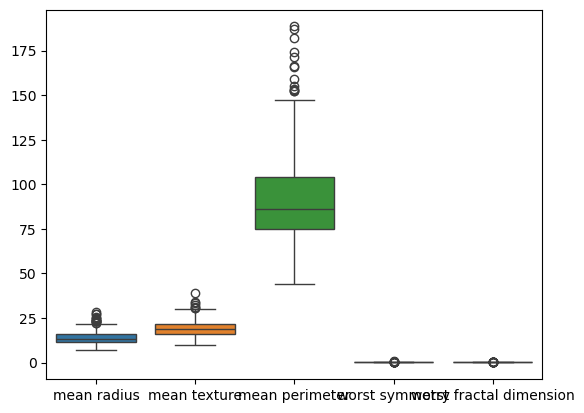

In [87]:
#outliers
sns.boxplot(data=df)
plt.show()

In [88]:
print(df.columns)

Index(['mean radius', 'mean texture', 'mean perimeter', 'worst symmetry',
       'worst fractal dimension', 'target'],
      dtype='object')


In [90]:
#handle missing values by filling them with mean for numerical columns and mode for categorical columns 
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Fill categorical missing values with mode
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(df.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


C:\Users\kruth\AppData\Local\Temp\ipykernel_24516\141340202.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
C:\Users\kruth\AppData\Local\Temp\ipykernel_24516\141340202.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

In [91]:
#handle outliers
numerical_cols = df.select_dtypes(include=np.number).columns

# Calculate Q1 and Q3
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Detect outliers
outliers = ((df[numerical_cols] < (Q1 - 1.5 * IQR)) |
            (df[numerical_cols] > (Q3 + 1.5 * IQR)))

In [92]:
# Remove rows containing outliers
df_clean = df[~((df[numerical_cols] < (Q1 - 1.5 * IQR)) |
                (df[numerical_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

In [93]:
#replace outliers with median
for col in numerical_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    median = df[col].median()

    df[col] = np.where(df[col] < lower, median, df[col])
    df[col] = np.where(df[col] > upper, median, df[col])

print("Outliers handled successfully")

Outliers handled successfully


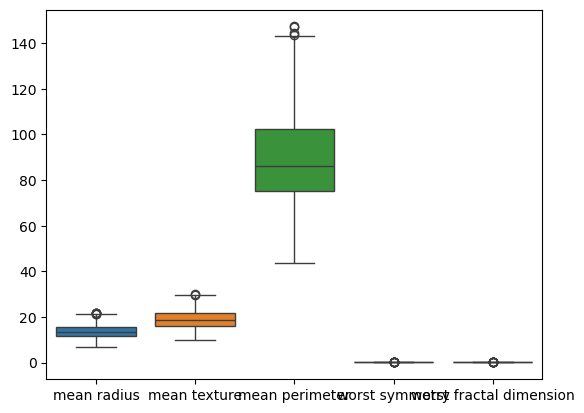

In [94]:
#outliers after removal
sns.boxplot(data=df)
plt.show()

In [95]:
print(df.head())

   mean radius  mean texture  mean perimeter  worst symmetry  \
0        17.99         10.38          122.80          0.2822   
1        20.57         17.77          132.90          0.2750   
2        19.69         21.25          130.00          0.3613   
3        11.42         20.38           77.58          0.2822   
4        20.29         14.34          135.10          0.2364   

   worst fractal dimension     target  
0                  0.11890  Malignant  
1                  0.08902  Malignant  
2                  0.08758  Malignant  
3                  0.08004  Malignant  
4                  0.07678  Malignant  


In [ ]:
target_col = df.columns[-1]
print("Target Column:", target_col)

Target Column: target


In [58]:
#encode the target variable
encoder = LabelEncoder()
df[target_col] = encoder.fit_transform(df[target_col])
X = df.drop(target_col, axis=1)
y = df[target_col]

In [59]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [97]:

# Features and target
X = df.drop('target', axis=1)
y = df['target']

# Check classes
print(y.value_counts())

# Feature scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

target
Benign       357
Malignant    212
Name: count, dtype: int64


In [98]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Train model
model = LogisticRegression()

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion matrix
print(confusion_matrix(y_test, y_pred))

# Classification report
print(classification_report(y_test, y_pred))

Accuracy: 0.9210526315789473
[[68  4]
 [ 5 37]]
              precision    recall  f1-score   support

      Benign       0.93      0.94      0.94        72
   Malignant       0.90      0.88      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



In [99]:
# Train the logistic regression model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [100]:
# Make predictions
y_pred = model.predict(X_test)
print(y_pred)

['Benign' 'Malignant' 'Malignant' 'Malignant' 'Benign' 'Benign'
 'Malignant' 'Benign' 'Benign' 'Benign' 'Malignant' 'Benign' 'Malignant'
 'Benign' 'Benign' 'Benign' 'Benign' 'Benign' 'Malignant' 'Benign'
 'Benign' 'Benign' 'Malignant' 'Malignant' 'Malignant' 'Benign' 'Benign'
 'Benign' 'Malignant' 'Malignant' 'Malignant' 'Benign' 'Malignant'
 'Malignant' 'Benign' 'Benign' 'Benign' 'Benign' 'Malignant' 'Benign'
 'Benign' 'Benign' 'Benign' 'Benign' 'Benign' 'Malignant' 'Benign'
 'Malignant' 'Benign' 'Benign' 'Malignant' 'Malignant' 'Benign' 'Benign'
 'Benign' 'Malignant' 'Benign' 'Benign' 'Benign' 'Malignant' 'Benign'
 'Benign' 'Malignant' 'Benign' 'Benign' 'Benign' 'Malignant' 'Malignant'
 'Benign' 'Benign' 'Benign' 'Malignant' 'Malignant' 'Benign' 'Benign'
 'Benign' 'Benign' 'Malignant' 'Benign' 'Malignant' 'Malignant'
 'Malignant' 'Benign' 'Benign' 'Benign' 'Benign' 'Malignant' 'Malignant'
 'Malignant' 'Benign' 'Malignant' 'Benign' 'Benign' 'Benign' 'Benign'
 'Benign' 'Malignant' 'Mal

In [101]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9210526315789473


In [102]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[68  4]
 [ 5 37]]
